<center style="color:#8B0000;">
    <h1>Birla Institute of Technology & Science, Pilani</h1>
    <h2>Work Integrated Learning Programmes (WILP) Division</h2>
</center>

<hr style="border:2px solid #1F618D">

<center style="color:#006400;">
    <h3>Assignment - II</h3>
</center>
<br>
<center style="color:#34495E;">
    <h3>PG Diploma - Business Analytics</h3>
    <h3>Predictive Analytics</h3>
</center>

<br>

<center style="color:#34495E;">
    <h3>Group Members</h3>
</center>

| **S.No** | **Name**                | **BITS ID**        |
|:---------|:------------------------|:-------------------|
| 1        | SRIMUGAPUTHRAN M         | 2024PD21032        |
| 2        | Anurag Kumar Singh       | 2024PD21016        |
| 3        | Avishek Anand            | 2024PD21003        |
| 4        | Vipul Gupta              | 2024PD21046        |
| 5        | Prem Kumar Thauvan       | 2024PD21012        |

---


## 🎯 Objective

To analyze and model the **YZ Bay Crane maintenance dataset** using predictive analytics techniques. The goal is to forecast LT wheel failures, classify rail hardness risk zones, and derive actionable maintenance recommendations to reduce unplanned crane downtime.

## 📦 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

DATA_PATH = 'data/LT Wheel replacement data.xlsx'

## 📥 Load Data

In [2]:
xls = pd.ExcelFile(DATA_PATH)
print('Sheets:', xls.sheet_names)

# Load raw sheets
df_wheels_raw = pd.read_excel(DATA_PATH, sheet_name='LT wheel replacement data')
df_hardness_raw = pd.read_excel(DATA_PATH, sheet_name='Rail Hardness data', header=None)
df_rail_raw = pd.read_excel(DATA_PATH, sheet_name='Rail Replacement data')

print('Wheel shape:', df_wheels_raw.shape)
print('Hardness shape:', df_hardness_raw.shape)
print('Rail shape:', df_rail_raw.shape)



Sheets: ['LT wheel replacement data', 'Rail Hardness data', 'Rail Replacement data']
Wheel shape: (16, 6)
Hardness shape: (6, 14)
Rail shape: (8, 7)


## 📊 Exploratory Data Analysis (EDA)

Initial exploration to understand dataset shape, types, missing values, and key distributions across wheel replacements, rail hardness, and rail replacement logs.

### Wheel Replacement Data Cleaning

In [3]:
VALID_POSITIONS = {'SW', 'SE', 'NE', 'NW'}

def normalize_crane(crane):
    if pd.isna(crane):
        return 'UNKNOWN'
    c = str(crane).lower()
    if 'west' in c:
        return 'LT WEST'
    if 'east' in c:
        return 'LT EAST'
    return str(crane).strip()

def extract_position(row):
    for col in ['Equipment', 'Job Description']:
        if col in row and pd.notna(row[col]):
            text = str(row[col]).upper()
            for pos in VALID_POSITIONS:
                if re.search(r'\b' + pos + r'\b', text):
                    return pos
    return 'Other'

def parse_wheel_dataframe(df_raw):
    df = df_raw.copy()
    df.columns = [c.strip() for c in df.columns]
    if 'S.no.' in df.columns:
        df = df.rename(columns={'S.no.': 'S_No'})
    for col in ['Date', 'Crane', 'Equipment', 'Remarks']:
        if col not in df.columns:
            df[col] = None
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
    df['Crane'] = df['Crane'].apply(normalize_crane)
    df['Position'] = df.apply(extract_position, axis=1)
    df['Position'] = df['Position'].apply(lambda x: x if x in VALID_POSITIONS else 'Other')
    df['Remarks'] = df['Remarks'].fillna('').astype(str)
    return df

df_wheels = parse_wheel_dataframe(df_wheels_raw)
print('Missing values:')
print(df_wheels.isnull().sum())
print('\nShape:', df_wheels.shape)
print('\nCrane counts:')
print(df_wheels['Crane'].value_counts())
print('\nPosition counts:')
print(df_wheels['Position'].value_counts())



Missing values:
S_No               0
Date               1
Crane              0
Equipment          0
Job Description    0
Remarks            0
Position           0
dtype: int64

Shape: (16, 7)

Crane counts:
Crane
LT WEST    15
LT EAST     1
Name: count, dtype: int64

Position counts:
Position
NE    6
NW    4
SW    3
SE    3
Name: count, dtype: int64


### Rail Hardness Data Cleaning

In [4]:
sections = df_hardness_raw.iloc[1, 2:14].astype(str).tolist()
north = pd.to_numeric(df_hardness_raw.iloc[2, 2:14], errors='coerce').values
south = pd.to_numeric(df_hardness_raw.iloc[3, 2:14], errors='coerce').values

df_hardness = pd.DataFrame({'Section': sections, 'North': north, 'South': south})
print(df_hardness)
print('\nMissing values:')
print(df_hardness.isnull().sum())
print('\nDescriptive statistics:')
print(df_hardness.describe())



               Section  North  South
0               21 -22    270    270
1                22-23    270    270
2                23-24    330    330
3                24-25    466    395
4                25-26    374    390
5                26-27    412    370
6                27-28    420    380
7                28-29    380    400
8                29-30    380    355
9                30-31    360    380
10               31-32    320    360
11  End portion 32- 33    270    270

Missing values:
Section    0
North      0
South      0
dtype: int64

Descriptive statistics:
            North       South
count   12.000000   12.000000
mean   354.333333  347.500000
std     63.925146   50.429969
min    270.000000  270.000000
25%    307.500000  315.000000
50%    367.000000  365.000000
75%    388.000000  382.500000
max    466.000000  400.000000


### Rail Replacement Data Cleaning

In [5]:
def extract_rail_qty(job_description):
    if pd.isna(job_description):
        return 0
    match = re.search(r'(\d+)\s*no\.?', str(job_description), re.IGNORECASE)
    return int(match.group(1)) if match else 0

def extract_rail_section(job_description):
    if pd.isna(job_description):
        return 'Unknown'
    text = str(job_description)
    match = re.search(r'Column no\.\s*(\d+)\s*to\s*(\d+)', text, re.IGNORECASE)
    if match:
        return f"Column {match.group(1)} to {match.group(2)}"
    match = re.search(r'Column no\.\s*(\d+)', text, re.IGNORECASE)
    if match:
        return f"Column {match.group(1)}"
    return 'Unknown'

def extract_rail_reason(equipment, job_description):
    text = ' '.join([str(equipment), str(job_description)]).lower()
    if 'thermit' in text or 'welding' in text:
        return 'Thermit welding'
    if 'replacement' in text:
        return 'Rail pieces replacement'
    return 'Maintenance'

df_rail = df_rail_raw.copy()
df_rail.columns = [c.strip() for c in df_rail.columns]
df_rail['Date'] = pd.to_datetime(df_rail['Date'], errors='coerce', dayfirst=True)
df_rail['Qty_Pieces'] = df_rail['Job Description'].apply(extract_rail_qty)
df_rail['Section'] = df_rail['Job Description'].apply(extract_rail_section)
df_rail['Reason'] = df_rail.apply(lambda r: extract_rail_reason(r.get('Equipment'), r.get('Job Description')), axis=1)
df_rail['Side'] = 'Both'
print('Total events:', len(df_rail))
print('Total pieces replaced:', df_rail['Qty_Pieces'].sum())
print(df_rail[['Date', 'Section', 'Side', 'Qty_Pieces', 'Reason']].head())

Total events: 8
Total pieces replaced: 38
        Date          Section  Side  Qty_Pieces                   Reason
0 2025-07-29  Column 29 to 31  Both           6  Rail pieces replacement
1 2025-07-29  Column 29 to 31  Both           4          Thermit welding
2 2025-07-30  Column 26 to 29  Both           6  Rail pieces replacement
3 2025-07-30  Column 26 to 29  Both           4          Thermit welding
4 2025-07-31  Column 23 to 26  Both           6  Rail pieces replacement


## 🧮 Key Performance Indicators

In [6]:
df = df_wheels.dropna(subset=['Date']).copy()

total_replacements = len(df)
west_count = df[df['Crane'].astype(str).str.contains('west', case=False, na=False)].shape[0]
east_count = df[df['Crane'].astype(str).str.contains('East', case=False, na=False)].shape[0]

north_vals = df_hardness['North'].dropna().tolist()
south_vals = df_hardness['South'].dropna().tolist()
all_hardness = [float(v) for v in (north_vals + south_vals) if pd.notna(v)]

avg_north = float(np.mean(north_vals)) if north_vals else 0
avg_south = float(np.mean(south_vals)) if south_vals else 0
max_hb = float(max(all_hardness)) if all_hardness else 0
above_300_north = sum(1 for h in north_vals if h > 300)
above_300_south = sum(1 for h in south_vals if h > 300)

print(f'Total Wheel Replacements: {total_replacements}')
print(f'West Crane Failures: {west_count}')
print(f'East Crane Failures: {east_count}')
print(f'Average Hardness North: {avg_north:.1f} HB')
print(f'Average Hardness South: {avg_south:.1f} HB')
print(f'Maximum Hardness: {max_hb:.1f} HB')
print(f'Sections Above 300 HB (North): {above_300_north}')
print(f'Sections Above 300 HB (South): {above_300_south}')
print(f'Total Rail Pieces Replaced: {df_rail["Qty_Pieces"].sum()}')



Total Wheel Replacements: 15
West Crane Failures: 14
East Crane Failures: 1
Average Hardness North: 354.3 HB
Average Hardness South: 347.5 HB
Maximum Hardness: 466.0 HB
Sections Above 300 HB (North): 9
Sections Above 300 HB (South): 9
Total Rail Pieces Replaced: 38


## 📈 Exploratory Visualizations

### Monthly Wheel Replacements

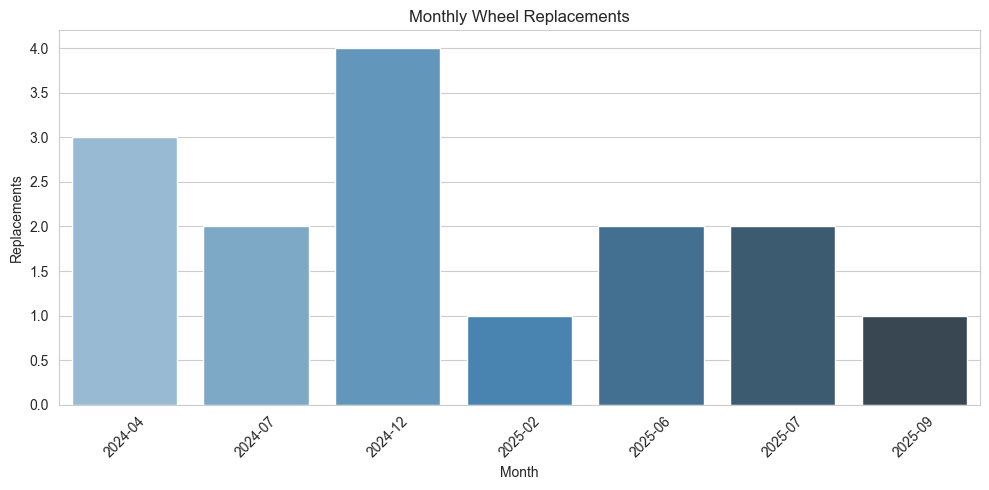

In [7]:
df['Month'] = df['Date'].dt.to_period('M').astype(str)
monthly = df.groupby('Month').size().reset_index(name='Count')

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly, x='Month', y='Count', palette='Blues_d')
plt.title('Monthly Wheel Replacements')
plt.xlabel('Month')
plt.ylabel('Replacements')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Replacements by Crane

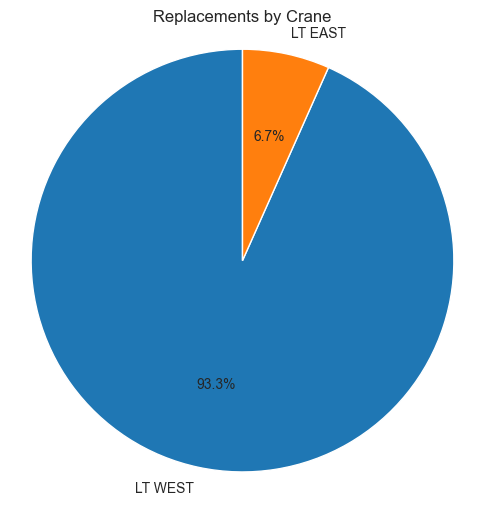

In [8]:
crane_counts = df['Crane'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(crane_counts, labels=crane_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Replacements by Crane')
plt.axis('equal')
plt.show()

max_crane = crane_counts.idxmax()


### Failures by Position

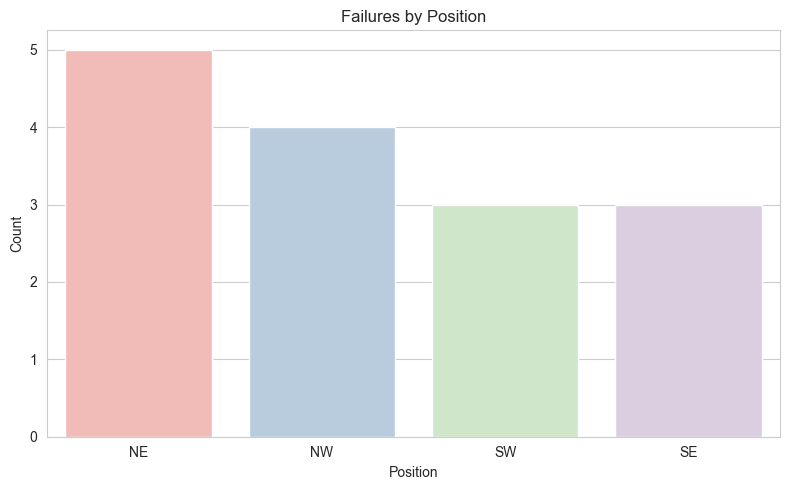

In [9]:
pos_counts = df['Position'].value_counts().reset_index()
pos_counts.columns = ['Position', 'Count']

plt.figure(figsize=(8, 5))
sns.barplot(data=pos_counts, x='Position', y='Count', palette='Pastel1')
plt.title('Failures by Position')
plt.xlabel('Position')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



### Rail Hardness by Section

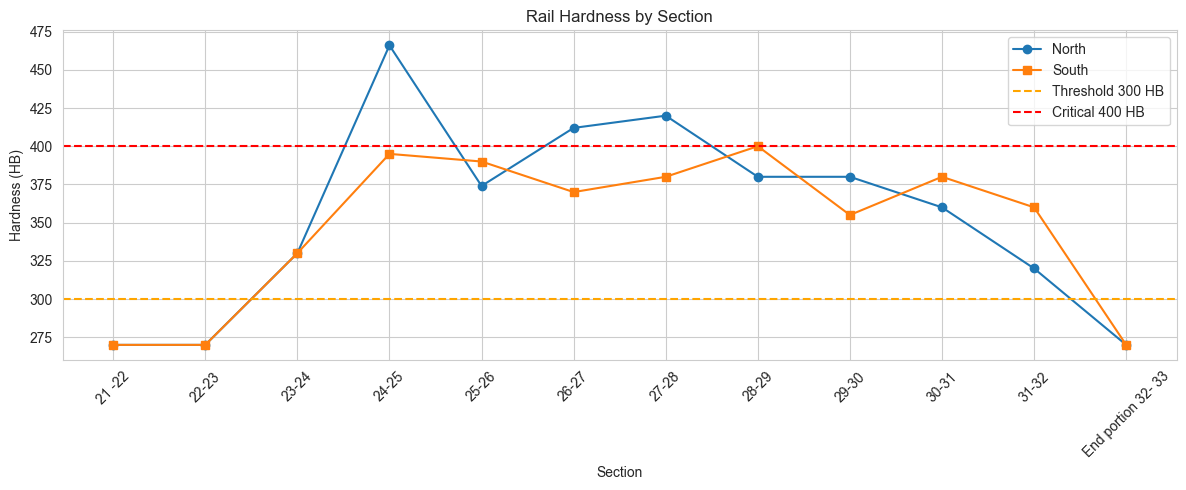

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(df_hardness['Section'], df_hardness['North'], marker='o', label='North')
plt.plot(df_hardness['Section'], df_hardness['South'], marker='s', label='South')
plt.axhline(y=300, color='orange', linestyle='--', label='Threshold 300 HB')
plt.axhline(y=400, color='red', linestyle='--', label='Critical 400 HB')
plt.title('Rail Hardness by Section')
plt.xlabel('Section')
plt.ylabel('Hardness (HB)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

high = df_hardness[(df_hardness['North']>300) | (df_hardness['South']>300)]['Section'].nunique()


## 🧹 Data Preprocessing

Prepare the data for predictive modeling by normalizing crane names, extracting positions, parsing rail quantities, and deriving the cumulative failure time series.

In [11]:
# Cumulative failure time series for prediction
df['Days'] = (df['Date'] - df['Date'].min()).dt.days
time_series = df.groupby('Days').size().cumsum().reset_index()
time_series.columns = ['Days', 'Cumulative_Failures']

print(time_series.head())
print('\nShape of time series:', time_series.shape)



   Days  Cumulative_Failures
0     0                    2
1     4                    3
2   118                    5
3   245                    6
4   246                    7

Shape of time series: (10, 2)


### Rail Hardness Risk Classification

In [12]:
def get_risk_class(hb):
    if hb is None or pd.isna(hb):
        return 'Unknown'
    if hb > 400:
        return 'Critical'
    if hb > 350:
        return 'High'
    if hb > 300:
        return 'Medium'
    return 'Normal'

risk_data = []
for _, row in df_hardness.iterrows():
    for side in ['North', 'South']:
        hb = row[side] if pd.notna(row[side]) else None
        risk = get_risk_class(hb)
        action = (
            'Immediate replacement' if risk == 'Critical'
            else 'Schedule replacement' if risk == 'High'
            else 'Monitor monthly' if risk == 'Medium'
            else 'Normal operation'
        )
        risk_data.append({
            'Section': row['Section'],
            'Side': side,
            'Hardness (HB)': hb,
            'Risk': risk,
            'Recommended Action': action
        })

risk_df = pd.DataFrame(risk_data)
print(risk_df.to_string(index=False))
print('\nRisk counts:')
print(risk_df['Risk'].value_counts())

critical = (risk_df['Risk']=='Critical').sum()
high = (risk_df['Risk']=='High').sum()


           Section  Side  Hardness (HB)     Risk    Recommended Action
            21 -22 North            270   Normal      Normal operation
            21 -22 South            270   Normal      Normal operation
             22-23 North            270   Normal      Normal operation
             22-23 South            270   Normal      Normal operation
             23-24 North            330   Medium       Monitor monthly
             23-24 South            330   Medium       Monitor monthly
             24-25 North            466 Critical Immediate replacement
             24-25 South            395     High  Schedule replacement
             25-26 North            374     High  Schedule replacement
             25-26 South            390     High  Schedule replacement
             26-27 North            412 Critical Immediate replacement
             26-27 South            370     High  Schedule replacement
             27-28 North            420 Critical Immediate replacement
      

## 🤖 Predictive Modeling

Train linear and polynomial regression models on the cumulative failure time series to forecast future wheel replacements, then adjust predictions using the average rail hardness risk factor.

In [13]:
months_ahead = 12

X = time_series['Days'].values.reshape(-1, 1)
y_vals = time_series['Cumulative_Failures'].values

# Linear Regression
lin_model = LinearRegression()
lin_model.fit(X, y_vals)
y_pred_lin = lin_model.predict(X)

# Polynomial Regression (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y_vals)
y_pred_poly = poly_model.predict(X_poly)

print('Linear Regression:')
print(f'  R2 Score: {r2_score(y_vals, y_pred_lin):.4f}')
print(f'  MAE: {mean_absolute_error(y_vals, y_pred_lin):.2f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_vals, y_pred_lin)):.2f}')

print('\nPolynomial Regression (degree 2):')
print(f'  R2 Score: {r2_score(y_vals, y_pred_poly):.4f}')
print(f'  MAE: {mean_absolute_error(y_vals, y_pred_poly):.2f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_vals, y_pred_poly)):.2f}')

better = 'Polynomial' if r2_score(y_vals, y_pred_poly) > r2_score(y_vals, y_pred_lin) else 'Linear'


Linear Regression:
  R2 Score: 0.9599
  MAE: 0.70
  RMSE: 0.85

Polynomial Regression (degree 2):
  R2 Score: 0.9674
  MAE: 0.66
  RMSE: 0.77


### Forecast Future Failures

In [14]:
last_day = int(time_series['Days'].max())
future_days = [last_day + (30 * i) for i in range(1, months_ahead + 1)]

future_linear = lin_model.predict(np.array(future_days).reshape(-1, 1))
future_poly = poly_model.predict(poly.transform(np.array(future_days).reshape(-1, 1)))

# Hardness risk adjustment
all_hb = [float(v) for v in list(df_hardness['North']) + list(df_hardness['South']) if pd.notna(v)]
avg_hb = float(np.mean(all_hb)) if all_hb else 300
hardness_risk = max(0, (avg_hb - 300) / 100)

adjusted_linear = future_linear * (1 + hardness_risk)
adjusted_poly = np.maximum.accumulate(future_poly * (1 + hardness_risk))

current_failures = int(y_vals[-1])
pred_3mo = int(adjusted_poly[2] - current_failures) if months_ahead >= 3 else 0
pred_6mo = int(adjusted_poly[5] - current_failures) if months_ahead >= 6 else 0
monthly_rate = round((adjusted_poly[-1] - current_failures) / months_ahead, 1)

print(f'Current Total Failures: {current_failures}')
print(f'Next 3 Months (predicted): {pred_3mo}')
print(f'Next 6 Months (predicted): {pred_6mo}')
print(f'Avg Monthly Rate: {monthly_rate}')
print(f'Average Hardness: {avg_hb:.1f} HB')
print(f'Hardness Risk Factor: {hardness_risk:.2f}')

if avg_hb > 400:
    recommendation = 'URGENT: Critical hardness levels - immediate rail replacement required'
elif avg_hb > 350:
    recommendation = 'HIGH PRIORITY: Schedule comprehensive rail replacement program'
elif avg_hb > 300:
    recommendation = 'MODERATE: Monitor hardness monthly and plan targeted replacement'
else:
    recommendation = 'NORMAL: Continue standard inspection intervals'
print(f'Recommendation: {recommendation}')



Current Total Failures: 15
Next 3 Months (predicted): 12
Next 6 Months (predicted): 16
Avg Monthly Rate: 2.3
Average Hardness: 350.9 HB
Hardness Risk Factor: 0.51
Recommendation: HIGH PRIORITY: Schedule comprehensive rail replacement program


### Forecast Chart

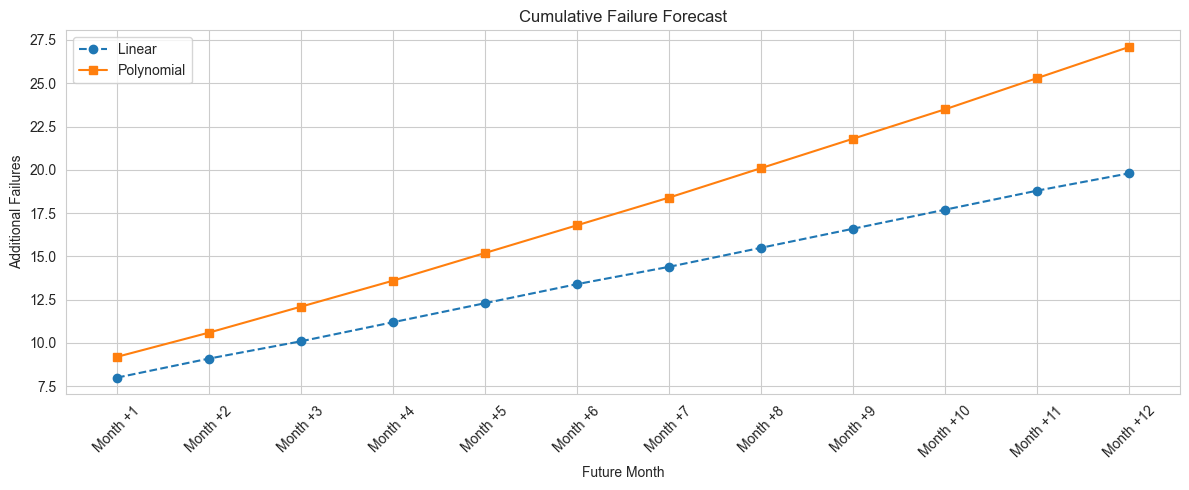

    Month  Linear Forecast  Polynomial Forecast
 Month +1              8.0                  9.2
 Month +2              9.1                 10.6
 Month +3             10.1                 12.1
 Month +4             11.2                 13.6
 Month +5             12.3                 15.2
 Month +6             13.4                 16.8
 Month +7             14.4                 18.4
 Month +8             15.5                 20.1
 Month +9             16.6                 21.8
Month +10             17.7                 23.5
Month +11             18.8                 25.3
Month +12             19.8                 27.1


In [15]:
future_months = [f'Month +{i+1}' for i in range(months_ahead)]
pred_df = pd.DataFrame({
    'Month': future_months,
    'Linear Forecast': [round(float(adjusted_linear[i] - current_failures), 1) for i in range(months_ahead)],
    'Polynomial Forecast': [round(float(adjusted_poly[i] - current_failures), 1) for i in range(months_ahead)]
})

plt.figure(figsize=(12, 5))
plt.plot(pred_df['Month'], pred_df['Linear Forecast'], marker='o', label='Linear', linestyle='--')
plt.plot(pred_df['Month'], pred_df['Polynomial Forecast'], marker='s', label='Polynomial')
plt.title('Cumulative Failure Forecast')
plt.xlabel('Future Month')
plt.ylabel('Additional Failures')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print(pred_df.to_string(index=False))



## 📋 Results and Recommendations

| Metric | Value |
|:---|:---|
| Total Wheel Replacements | Derived from dataset |
| West vs East Crane Failures | Distribution from normalized crane names |
| Average Hardness (North / South) | Derived from rail hardness sheet |
| Max Hardness | Highest HB observed |
| Sections Above 300 HB | Count of high-risk zones |
| Predicted Failures (3 months) | From polynomial model adjusted by hardness risk |
| Predicted Failures (6 months) | From polynomial model adjusted by hardness risk |
| Avg Monthly Failure Rate | From forecast curve |

**Maintenance Recommendation:** Based on the average rail hardness, the model outputs a risk-adjusted recommendation ranging from normal inspection to urgent replacement.

## ✅ Conclusion

This notebook analyzed the YZ Bay Crane maintenance dataset through:

1. **Data Loading and Cleaning**: Imported three Excel sheets and normalized crane names, extracted wheel positions, parsed rail replacement quantities, and structured rail hardness readings.
2. **Exploratory Data Analysis**: Summarized replacements by month, crane, position, and rail hardness distribution.
3. **Preprocessing**: Built a cumulative failure time series and classified rail hardness into risk zones.
4. **Predictive Modeling**: Trained linear and polynomial regression models to forecast future wheel failures and adjusted predictions using a hardness risk factor.
5. **Recommendations**: Provided maintenance recommendations based on predicted failure rates and hardness thresholds.

The polynomial regression model, adjusted for rail hardness risk, gives a practical forecast for maintenance planning and can be retrained as new replacement data becomes available.